## Disciplina VIS101: Fundamentos em Visão Computacional

### Do histograma à decisão: threshold

O histograma é mais que um diagnóstico: ele orienta a primeira decisão automática que um sistema de visão toma. O threshold (limiarização) converte uma imagem em tons de cinza em uma imagem binária, separando os pixels em dois grupos a partir de um valor de corte.

Toda segmentação começa aqui: antes de detectar, contar ou medir qualquer objeto, é preciso decidir o que é figura e o que é fundo.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print(cv2.__version__)

4.13.0


### O histograma como mapa da decisão

A imagem de referência é convertida para tons de cinza e o histograma é recalculado. A pergunta agora é: onde passar a linha de corte que separa os grupos de pixels?

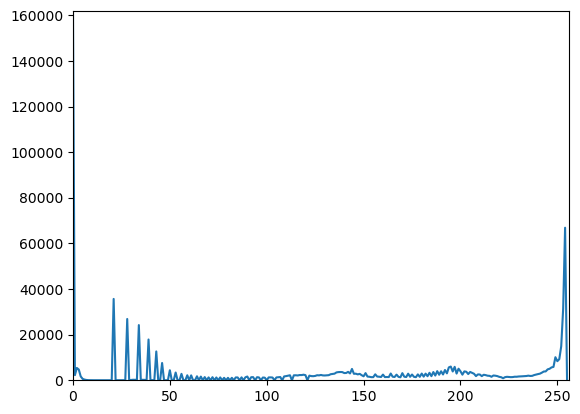

In [2]:
img = cv2.imread('../images/dog.png', 0) #igual a img = cv2.imread('data/carlos.jpg', cv2.IMREAD_GRAYSCALE)

hist = cv2.calcHist([img], [0], None, [256], [0, 256])

plt.plot(hist)
plt.xlim([0, 256])
plt.ylim([0, hist.max()])
plt.show()

### Threshold fixo

A função `cv2.threshold` recebe o valor de corte e o valor máximo. Todo pixel acima do corte vira 255; o resto vira 0. O retorno tem dois elementos: o limiar usado e a imagem binária.

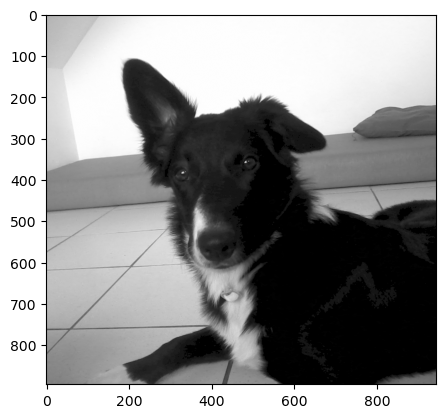

In [3]:
cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

plt.imshow(img, cmap='gray');
plt.show()

50.0


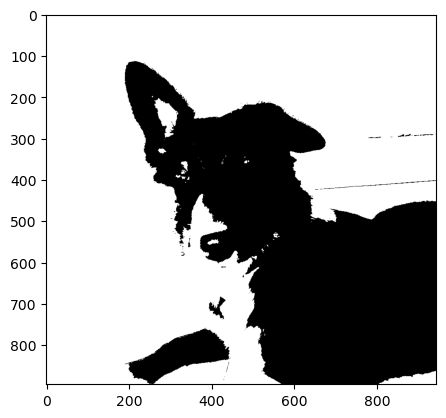

In [4]:
valor, binaria = cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)
print(valor)

plt.imshow(binaria, cmap='gray');
plt.show()

127.0


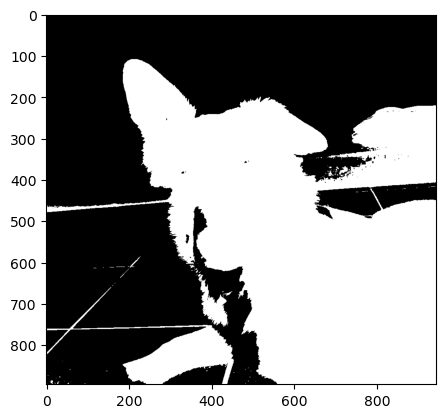

In [5]:
valor, inversa = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
print(valor)

plt.imshow(inversa, cmap='gray');
plt.show()

O corte em 127 é arbitrário. Mover o limiar muda o que sobrevive na imagem binária, e o histograma mostra por quê: cada posição da linha de corte reparte a distribuição em dois volumes diferentes.

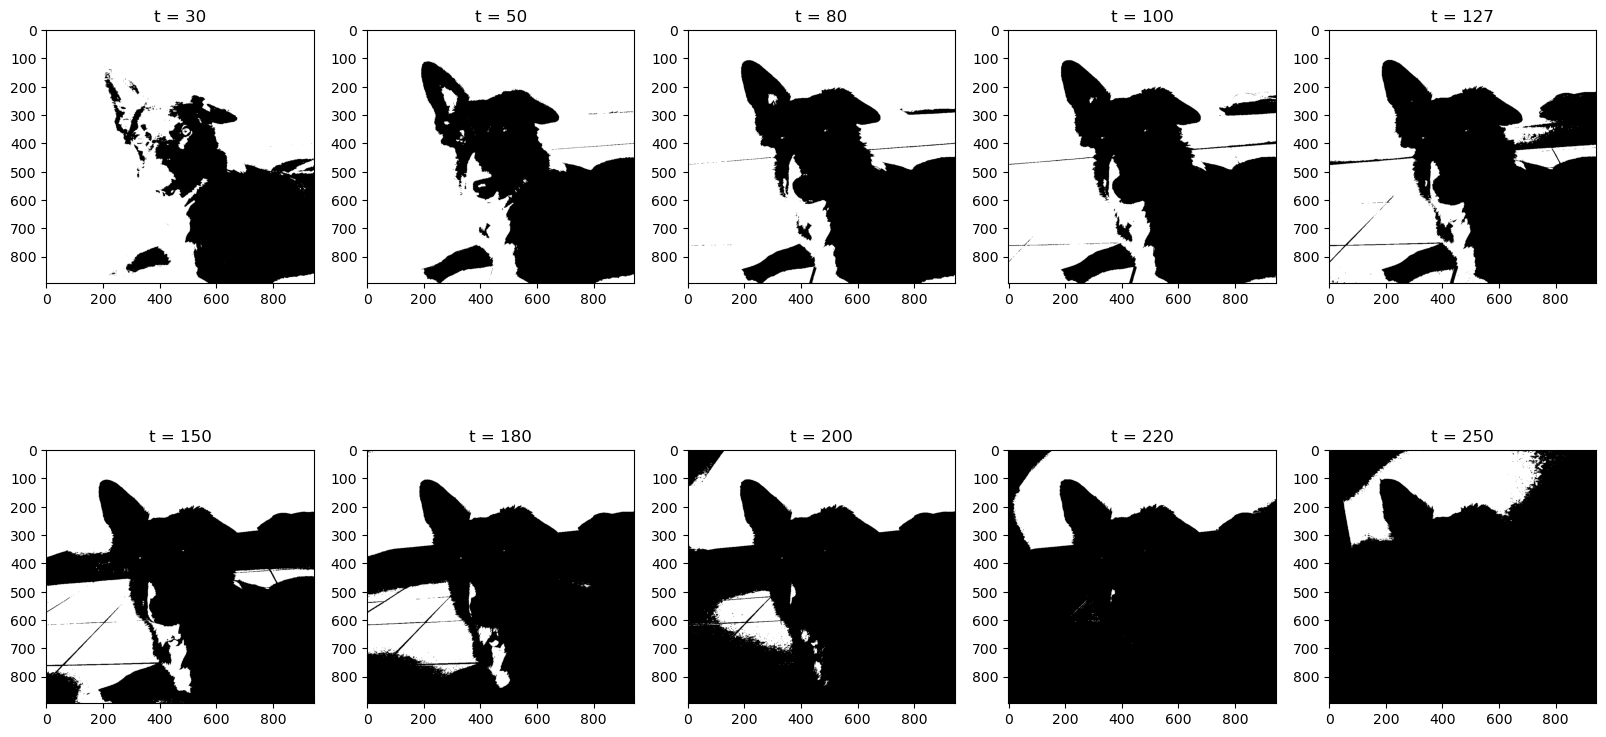

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
for ax, t in zip(axes.ravel(), [30, 50, 80, 100, 127, 150, 180, 200, 220, 250]):
    _, b = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
    ax.imshow(b, cmap='gray')
    ax.set_title(f't = {t}')
plt.show()

### Otsu: deixando o histograma decidir

Escolher o limiar no olho funciona para uma imagem, mas não escala. O método de Otsu varre o histograma e escolhe automaticamente o corte que melhor separa os dois grupos. É literalmente o histograma tomando a decisão.

Basta somar a flag THRESH_OTSU e passar 0 no lugar do limiar.

Uma ressalva: Otsu assume um histograma com dois grupos bem definidos (bimodal). Em imagens, que não tem essa característica, o resultado é apenas ilustrativo.

Limiar definido pelo Otsu: 114.0


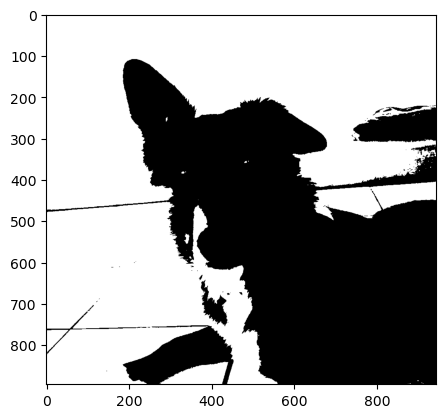

In [7]:
valor_otsu, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Limiar definido pelo Otsu: {valor_otsu}')

plt.imshow(otsu, cmap='gray');
plt.show()

### Quando o limiar global falha

Um único corte para a imagem inteira supõe iluminação uniforme. Uma rampa de luz simulada sobre a imagem quebra essa suposição: o mesmo objeto fica claro de um lado e escuro do outro.

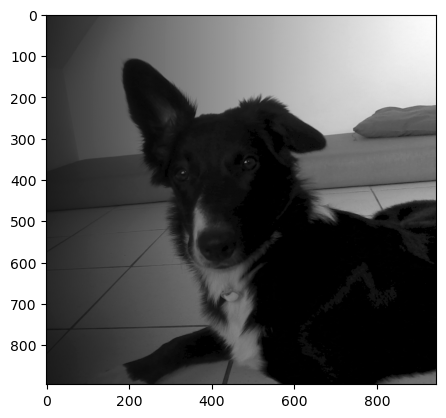

In [8]:
# 1. Obtém as dimensões exatas da imagem (altura e largura em pixels)
h, w = img.shape

# 2. Criação do filtro degradê (rampa de luz):
# - np.linspace: Cria uma linha matemática variando de 0.2 (20% de luz) até 1.0 (100% de luz), 
#   com a quantidade de valores igual à largura (w) da imagem.
# - np.tile: "Empilha" essa linha repetidas vezes para baixo, igual à altura (h) da imagem, 
#   formando uma matriz 2D de degradê do mesmo tamanho da foto original.
rampa = np.tile(np.linspace(0.2, 1.0, w), (h, 1))

# 3. Aplicação do filtro:
# Multiplica a imagem original pela matriz degradê, pixel por pixel. 
# O astype(np.uint8) garante que o resultado final em números decimais volte a 
# ser lido pelo computador como pixels válidos de imagem (inteiros de 0 a 255).
desigual = (img * rampa).astype(np.uint8)

# 4. Renderização visual da nova imagem em tons de cinza
plt.imshow(desigual, cmap='gray');
plt.show()

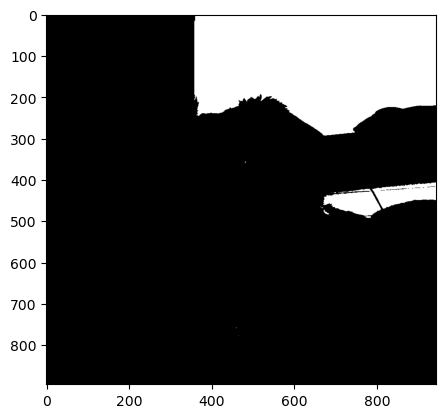

In [9]:
_, global_falha = cv2.threshold(desigual, 127, 255, cv2.THRESH_BINARY)

plt.imshow(global_falha, cmap='gray');
plt.show()

O lado escuro desaparece por inteiro: nenhum corte único resolve os dois lados ao mesmo tempo.

## Threshold adaptativo

O cv2.adaptiveThreshold calcula um limiar diferente para cada região da imagem, usando a vizinhança de cada pixel. Os dois últimos parâmetros são o tamanho da vizinhança (ímpar) e uma constante subtraída da média.



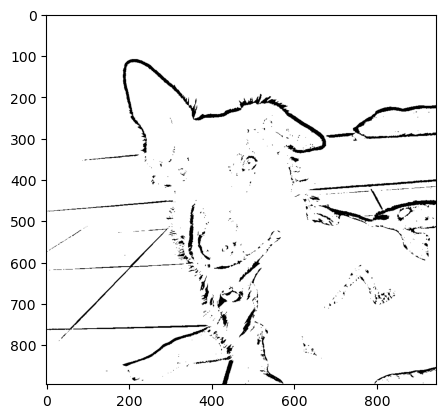

In [10]:
adaptativa = cv2.adaptiveThreshold(desigual, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                   cv2.THRESH_BINARY, 21, 10)

plt.imshow(adaptativa, cmap='gray');
plt.show()

### Limiarização Adaptativa (Adaptive Thresholding)

Diferente da limiarização global, que aplica uma única nota de corte matemática para toda a matriz, a **Limiarização Adaptativa** calcula o limiar dinamicamente para micro-regiões da imagem. Essa técnica é a solução padrão na indústria para contornar problemas de **iluminação espacial irregular** (sombreamentos, vinhetas ou gradientes direcionais).

O cálculo local exige a definição de uma vizinhança (`blockSize` — sempre um número ímpar, como 11 ou 21) e de uma constante de ajuste (`C`). O limiar de cada pixel central é calculado com base nos vizinhos através de dois métodos estatísticos principais:

1. **Média Aritmética (`cv2.ADAPTIVE_THRESH_MEAN_C`)**
   * **Mecanismo:** O limiar é a média simples de todos os pixels contidos na vizinhança subtraída da constante `C`.
   * **Comportamento:** Todos os pixels da região possuem o mesmo peso. É computacionalmente mais leve, porém mais suscetível a ruídos periféricos, tendendo a gerar contornos ligeiramente mais espessos e grosseiros.

2. **Média Gaussiana (`cv2.ADAPTIVE_THRESH_GAUSSIAN_C`)**
   * **Mecanismo:** O limiar é uma média ponderada cruzada (distribuição Gaussiana) da vizinhança subtraída da constante `C`. 
   * **Comportamento:** Pixels adjacentes ao centro possuem peso máximo na decisão estatística, enquanto a influência decai exponencialmente em direção às bordas da janela. O resultado preserva detalhes morfológicos de alta frequência (traços finos e texturas complexas) com superior rejeição a ruídos aleatórios. É a escolha primária no pré-processamento de pipelines de *Deep Learning* e reconhecimento óptico de caracteres (OCR).

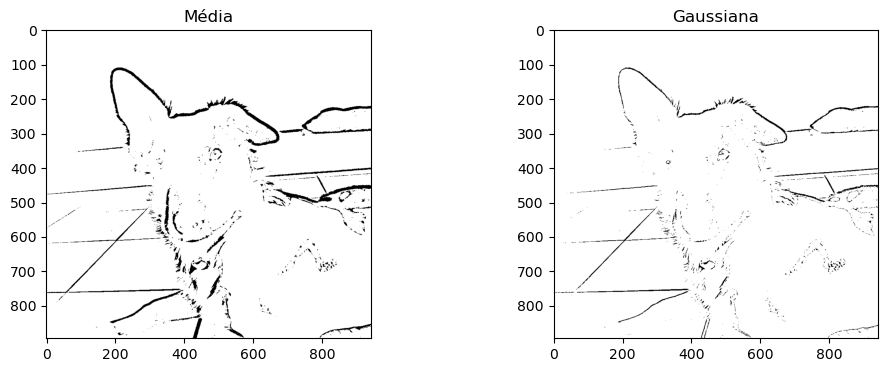

In [11]:
gaussiana = cv2.adaptiveThreshold(desigual, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 21, 10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(adaptativa, cmap='gray')
axes[0].set_title('Média')
axes[1].imshow(gaussiana, cmap='gray')
axes[1].set_title('Gaussiana')
plt.show()

A versão adaptativa recupera a estrutura nos dois lados da rampa, porque cada região decide com base na própria vizinhança.

### Aplicação: separando moedas do fundo

Fechando o ciclo com um caso concreto: as moedas sobre a mesa, uma imagem com dois grupos claros no histograma (mesa clara, moedas escuras), o cenário ideal de Otsu. Um borrão leve antes do threshold reduz o ruído. Como a mesa é mais clara que as moedas, a versão invertida (THRESH_BINARY_INV) deixa as moedas em branco, a convenção usual para a figura de interesse. As etapas seguintes do pipeline ficam para a disciplina de Processamento Digital de Imagens.

In [12]:
moedas = cv2.imread('../images/brasil-moedas.jpg')
moedas_gray = cv2.cvtColor(moedas, cv2.COLOR_BGR2GRAY)
suave = cv2.GaussianBlur(moedas_gray, (7, 7), 0)

valor_m, mascara = cv2.threshold(suave, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
print('Limiar de Otsu para as moedas:', valor_m)

Limiar de Otsu para as moedas: 203.0


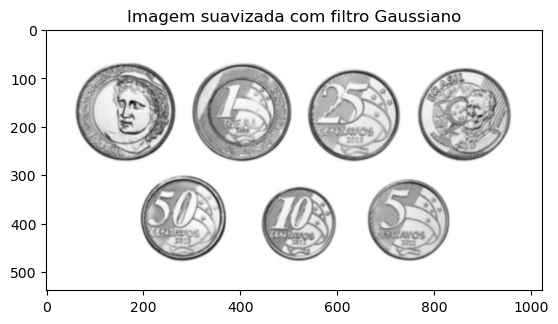

In [13]:
plt.imshow(suave, cmap='gray');
plt.title('Imagem suavizada com filtro Gaussiano');
plt.show()

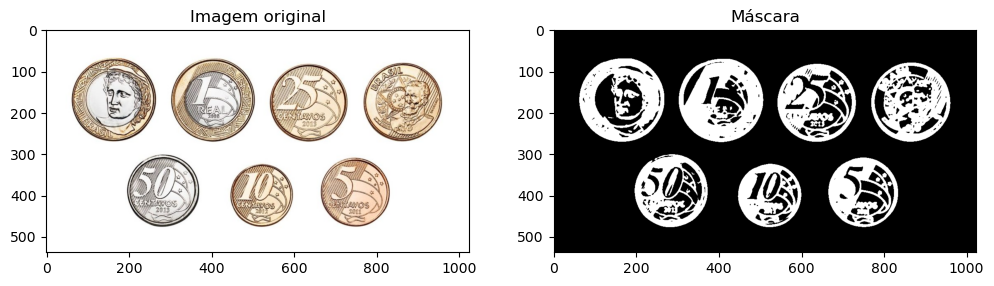

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(cv2.cvtColor(moedas, cv2.COLOR_BGR2RGB))
axes[0].set_title('Imagem original')
axes[1].imshow(mascara, cmap='gray')
axes[1].set_title('Máscara')
plt.show()

________________________
### Síntese: O pipeline da binarização

A construção de uma máscara binária é a base da segmentação de imagens e segue uma evolução lógica de complexidade:

* 📊 **Histograma:** Descreve a distribuição de intensidades.
* ✂️ **Threshold global:** Utiliza a leitura da distribuição para tomar uma decisão binária rígida (separando objeto de fundo).
* 🤖 **Método de Otsu:** Automatiza o processo global, calculando matematicamente o ponto de corte ideal sem a necessidade de testes manuais.
* 🔦 **Threshold Adaptativo:** Evolui a técnica para o mundo real, resolvendo as falhas do método global em cenários onde a iluminação não é uniforme (sombreamentos e gradientes).

> **💡 O Próximo Passo:**
> A imagem binária resultante deste pipeline é a porta de entrada definitiva para a **Segmentação de Imagens**, um tópico central que será posteriormente abordado em *Processamento Digital de Imagens (PDI)*.